In [2]:
# install and check GPU
!pip -q install -U transformers accelerate safetensors

import torch, transformers
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.6 MB/s eta 0:00:00
torch: 2.10.0+cu128
transformers: 5.3.0
CUDA: True
GPU: Tesla T4


In [3]:
# Imports
import os, re, ast
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [4]:
# Paths
DATA_TSV  = "dontpatronizeme_pcl.tsv"
TRAIN_CSV = "train_semeval_parids-labels.csv"
DEV_CSV   = "dev_semeval_parids-labels.csv"
TEST_TSV  = "task4_test.tsv"

os.makedirs("../BestModel", exist_ok=True)

In [5]:
# Load base TSV
rows, bad_lines = [], 0
with open(DATA_TSV, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) == 6:
            rows.append(parts)
        else:
            bad_lines += 1

print("Loaded rows:", len(rows), "Bad lines skipped:", bad_lines)

base = pd.DataFrame(rows, columns=["row_id","par_id","keyword","country","paragraph","label_0_4"])
base["row_id"] = pd.to_numeric(base["row_id"], errors="coerce")
base = base.dropna(subset=["row_id"]).copy()
base["row_id"] = base["row_id"].astype(int)
base["par_id"] = base["par_id"].astype(str)

base = base[["row_id","par_id","paragraph"]].copy()
base.head()

Loaded rows: 10469 Bad lines skipped: 4


,row_id,par_id,paragraph
0,1,@@24942188,"We 're living in times of absolute insanity , ..."
1,2,@@21968160,"In Libya today , there are countless number of..."
2,3,@@16584954,"""White House press secretary Sean Spicer said ..."
3,4,@@7811231,Council customers only signs would be displaye...
4,5,@@1494111,""""""" Just like we received migrants fleeing El ..."


In [6]:
# Load splits, merge, conver label vector to binary
train_ids = pd.read_csv(TRAIN_CSV).iloc[:, :2].copy()
dev_ids   = pd.read_csv(DEV_CSV).iloc[:, :2].copy()

train_ids.columns = ["row_id", "label"]
dev_ids.columns   = ["row_id", "label"]

train_ids["row_id"] = pd.to_numeric(train_ids["row_id"], errors="coerce")
dev_ids["row_id"]   = pd.to_numeric(dev_ids["row_id"], errors="coerce")
train_ids = train_ids.dropna(subset=["row_id"]).copy()
dev_ids   = dev_ids.dropna(subset=["row_id"]).copy()

train_ids["row_id"] = train_ids["row_id"].astype(int)
dev_ids["row_id"]   = dev_ids["row_id"].astype(int)

train_df = train_ids.merge(base, on="row_id", how="left").dropna(subset=["paragraph"]).copy()
dev_df   = dev_ids.merge(base, on="row_id", how="left").dropna(subset=["paragraph"]).copy()

train_df["label_vec"] = train_df["label"].apply(ast.literal_eval)
dev_df["label_vec"]   = dev_df["label"].apply(ast.literal_eval)

train_df["label_bin"] = train_df["label_vec"].apply(lambda v: int(sum(v) > 0))
dev_df["label_bin"]   = dev_df["label_vec"].apply(lambda v: int(sum(v) > 0))

print("Train bin dist:\n", train_df["label_bin"].value_counts(normalize=True))
print("Dev bin dist:\n", dev_df["label_bin"].value_counts(normalize=True))

train_df = train_df[["row_id","par_id","paragraph","label_bin"]].copy()
dev_df   = dev_df[["row_id","par_id","paragraph","label_bin"]].copy()

Train bin dist:
 label_bin
0    0.905194
1    0.094806
Name: proportion, dtype: float64
Dev bin dist:
 label_bin
0    0.904967
1    0.095033
Name: proportion, dtype: float64


In [7]:
# Light cleaning
def clean_text(text: str) -> str:
    text = re.sub(r"<.*?>", "", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text"] = train_df["paragraph"].apply(clean_text)
dev_df["text"]   = dev_df["paragraph"].apply(clean_text)

In [8]:
# Tokenizer + dynamic padding + datasets
MODEL_NAME = "roberta-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=MAX_LEN,
        )
        if self.labels is not None:
            enc["labels"] = int(self.labels[idx])
        return enc

train_ds = TextDataset(train_df["text"], train_df["label_bin"])
dev_ds   = TextDataset(dev_df["text"], dev_df["label_bin"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [9]:
# Class weights + weighted trainer
counts = train_df["label_bin"].value_counts().to_dict()
n0, n1 = counts.get(0, 1), counts.get(1, 1)

# cap weight to avoid extreme instability (not expected here, but safe)
pos_weight = min(n0 / n1, 8.0)
class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float)
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}

        outputs = model(**model_inputs)
        logits = outputs.get("logits")

        w = self.class_weights.to(device=logits.device, dtype=logits.dtype)
        loss_fct = nn.CrossEntropyLoss(weight=w)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

Class weights: tensor([1., 8.])


In [10]:
# Train
set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "f1_pos": f1_score(labels, preds, pos_label=1),
        "precision_pos": precision_score(labels, preds, pos_label=1, zero_division=0),
        "recall_pos": recall_score(labels, preds, pos_label=1, zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="../runs/roberta_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    max_grad_norm=1.0,
    fp16=False,
    bf16=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1_pos",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Pos,Precision Pos,Recall Pos
1,0.465653,0.259638,0.520000,0.466135,0.587940
2,0.521697,0.230822,0.533333,0.630137,0.462312
3,0.453189,0.336561,0.606061,0.565217,0.653266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1572, training_loss=0.461815242093938, metrics={'train_runtime': 725.388, 'train_samples_per_second': 34.637, 'train_steps_per_second': 2.167, 'total_flos': 1458215941015800.0, 'train_loss': 0.461815242093938, 'epoch': 3.0})

In [11]:
# Dev probs + threshold tuning + metrics
pred = trainer.predict(dev_ds)
dev_logits = pred.predictions
dev_labels = pred.label_ids

dev_probs = torch.softmax(torch.tensor(dev_logits), dim=-1)[:, 1].numpy()

thresholds = np.linspace(0.05, 0.95, 91)
best_t, best_f1 = 0.5, -1

for t in thresholds:
    yhat = (dev_probs >= t).astype(int)
    f1 = f1_score(dev_labels, yhat, pos_label=1)
    if f1 > best_f1:
        best_f1, best_t = f1, t

dev_preds = (dev_probs >= best_t).astype(int)

print("Best threshold:", best_t)
print("Best dev F1 (pos):", best_f1)
print("Precision (pos):", precision_score(dev_labels, dev_preds, pos_label=1, zero_division=0))
print("Recall (pos):", recall_score(dev_labels, dev_preds, pos_label=1, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(dev_labels, dev_preds))

Best threshold: 0.32999999999999996
Best dev F1 (pos): 0.6177777777777778
Precision (pos): 0.5537848605577689
Recall (pos): 0.6984924623115578
Confusion matrix:
 [[1783  112]
 [  60  139]]


In [12]:
import os, json

BESTMODEL_DIR = "../BestModel/model"
os.makedirs(BESTMODEL_DIR, exist_ok=True)

# Saves the current model in trainer.model — with load_best_model_at_end=True,
# Trainer will have loaded the best checkpoint at the end of training.
trainer.save_model(BESTMODEL_DIR)
tokenizer.save_pretrained(BESTMODEL_DIR)

# Save metadata (threshold, seed, etc.)
meta = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "seed": 42,
    "best_threshold": float(best_t),
}
with open("../BestModel/model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved best model to:", BESTMODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model to: ../BestModel/model


In [19]:
# Write BestModel/dev.txt
DEV_OUT = "../BestModel/dev.txt"
with open(DEV_OUT, "w") as f:
    for y in dev_preds:
        f.write(f"{int(y)}\n")

print("Wrote:", DEV_OUT, "Lines:", len(dev_pred))

Wrote: ../BestModel/dev.txt Lines: 2094


In [20]:
# Predict test + write BestModel/test.txt
test_rows, test_bad = [], 0
with open(TEST_TSV, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) == 5:
            test_rows.append(parts)
        else:
            test_bad += 1

print("Test loaded:", len(test_rows), "bad lines:", test_bad)

test_df = pd.DataFrame(test_rows, columns=["row_id","par_id","keyword","country","paragraph"])
test_df["text"] = test_df["paragraph"].apply(clean_text)

test_ds = TextDataset(test_df["text"], labels=None)

test_logits = trainer.predict(test_ds).predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()
test_pred = (test_probs >= best_t).astype(int)

TEST_OUT = "../BestModel/test.txt"
with open(TEST_OUT, "w") as f:
    for y in test_pred:
        f.write(f"{int(y)}\n")

print("Wrote:", TEST_OUT, "Lines:", len(test_pred))

Test loaded: 3832 bad lines: 0


Wrote: ../BestModel/test.txt Lines: 3832


In [ ]:
import shutil

zip_path = shutil.make_archive("../BestModel", "zip", "../BestModel")
print("Created:", zip_path)

Created: /BestModel.zip


In [ ]:
from google.colab import files
files.download("../BestModel.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
## Exercise 5.2 – Local Evaluation
### Error Analysis

In [13]:
dev_df["pred"] = dev_preds
dev_df["true"] = dev_df["label_bin"]
dev_df["prob"] = dev_probs

In [14]:
false_pos = dev_df[(dev_df["true"] == 0) & (dev_df["pred"] == 1)]
false_neg = dev_df[(dev_df["true"] == 1) & (dev_df["pred"] == 0)]

false_pos[["paragraph","prob"]].head(5)

,paragraph,prob
203,Marcos said the government should help poor fa...,0.987243
222,A crew of disabled athletes will be tackling t...,0.395572
262,""""""" This incident will not tear us down but ra...",0.880187
281,The Jali family in Brown 's Farm was elated as...,0.974211
286,"So , let the NPP government appointees look do...",0.990473


In [15]:
false_neg[["paragraph","prob"]].head(5)

,paragraph,prob
0,We also know that they can benefit by receivin...,0.012187
2,Many refugees do n't want to be resettled anyw...,0.009045
4,"""In a 90-degree view of his constituency , one...",0.022413
5,He depicts demonstrations by refugees at the b...,0.048843
8,t is remiss not to mention here that not all s...,0.018601


In [16]:
def show_examples(df, title, n=3):
    print("\n", title)
    print("="*80)

    for i,row in df.head(n).iterrows():
        print("\nProbability:", round(row["prob"],3))
        print("Text:", row["paragraph"])
        print("-"*80)

show_examples(false_pos, "False Positives")
show_examples(false_neg, "False Negatives")


 False Positives

Probability: 0.987
Text: Marcos said the government should help poor families that try every possible means to survive . With Joel Zurbano <h> More from this Category :
--------------------------------------------------------------------------------

Probability: 0.396
Text: A crew of disabled athletes will be tackling this weekend 's Chattanooga Waterfront Triathlon to show others with disabilities they , too , can participate in a healthy , active lifestyle .
--------------------------------------------------------------------------------

Probability: 0.88
Text: """ This incident will not tear us down but rather strengthen us as an organization . We will continue our mission of helping Veterans in need . It is through your generous donations and the volunteers in Chapter 84 that we have been able to provide transportation service for Veterans to their appointments at VA facilities and to build wheel chair ramps at no cost to the Veteran . There is scarcely a famil

In [ ]:
# Other local evaluation

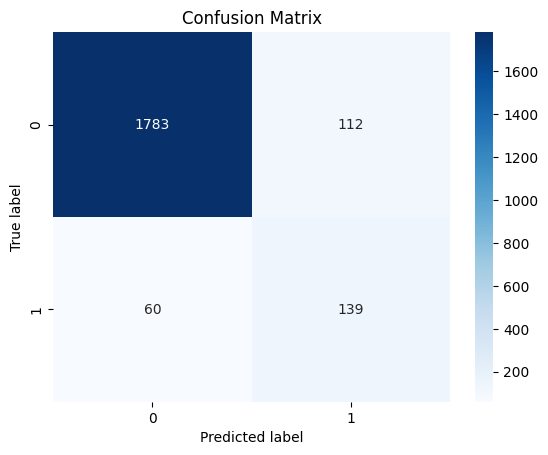

In [17]:
# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(dev_df["label_bin"], dev_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

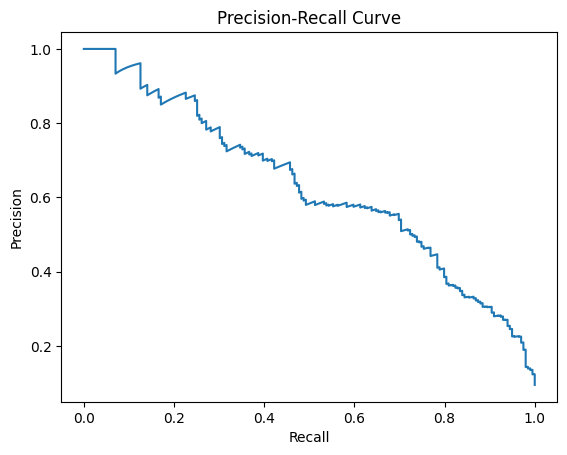

In [18]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(dev_df["label_bin"], dev_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()